# Modern Portfolio Theory with Russian Stocks

This notebook demonstrates Modern Portfolio Theory using Russian equities from MOEX.

Main goals:
- download market data,
- compare several optimization targets,
- compare long-only and short-allowed portfolios,
- impose an upper bound on one asset,
- visualize portfolio characteristics on the same graph,
- and show how dividend-adjusted returns can change the results.

Note:
This notebook uses MOEX ISS historical prices as the base dataset.

# Technical part
## Packages

In [ ]:
!pip install adjustText

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.optimize import minimize
from adjustText import adjust_text

## Settings

We choose a cross-sector universe of large Russian stocks.

You can change:
- the asset universe,
- the sample period,
- the risk-free rate,
- whether dividends are included.

In [ ]:
RISK_FREE_RATE = 0.16   # illustrative annual value
USE_DIVIDENDS = True    # switch between price return and total return

BASE_URL = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/TQBR/securities/{ticker}.json"

START_DATE = "2021-01-01"
END_DATE = "2026-02-27"

TICKERS = [
    "SBER",  # banking
    "LKOH",  # oil
    "MAGN",  # metals
    "MTSS",  # telecom
    "AFLT",  # transport
    "NVTK",  # gas
    "MOEX"   # exchange
]

BASE_HISTORY_URL = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/TQBR/securities/{ticker}.json"
BASE_DIVIDENDS_URL = "https://iss.moex.com/iss/securities/{ticker}/dividends.json?iss.meta=off"

## Price loader

In [ ]:
def build_price_returns(prices):
    return prices.pct_change().dropna()


def build_dividend_adjusted_returns(prices, dividend_events):
    """
    total_return_t = price_return_t + dividend_per_share / previous_close
    on the mapped trading date of the dividend event
    """
    total_returns = prices.pct_change()

    for _, row in dividend_events.iterrows():
        ticker = row["ticker"]
        trading_date = row["trading_date"]
        dividend_per_share = row["dividend_per_share"]

        if ticker not in prices.columns:
            continue
        if trading_date not in prices.index:
            continue

        loc = prices.index.get_loc(trading_date)
        if loc == 0:
            continue

        prev_close = prices[ticker].iloc[loc - 1]
        if pd.isna(prev_close) or prev_close <= 0:
            continue

        dividend_yield = dividend_per_share / prev_close
        total_returns.loc[trading_date, ticker] += dividend_yield

    return total_returns.dropna()

In [ ]:
def fetch_moex_history(ticker, start_date, end_date):
    start_row = 0
    all_chunks = []

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "start": start_row,
            "iss.meta": "off"
        }

        url = BASE_URL.format(ticker=ticker)
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        payload = r.json()

        columns = payload["history"]["columns"]
        data = payload["history"]["data"]

        if not data:
            break

        chunk = pd.DataFrame(data, columns=columns)
        all_chunks.append(chunk)

        if len(data) < 100:
            break

        start_row += 100

    if not all_chunks:
        print(f"No data for {ticker}")
        return None

    df = pd.concat(all_chunks, ignore_index=True)

    price_col = None
    for col in ["CLOSE", "LEGALCLOSEPRICE", "MARKETPRICE2", "MARKETPRICE3", "WAPRICE"]:
        if col in df.columns:
            price_col = col
            break

    if price_col is None:
        print(f"No valid price column for {ticker}")
        return None

    out = df[["TRADEDATE", price_col]].copy()
    out.columns = ["date", ticker]
    out["date"] = pd.to_datetime(out["date"])
    out[ticker] = pd.to_numeric(out[ticker], errors="coerce")
    out = out.dropna().drop_duplicates(subset="date").sort_values("date")
    out = out.set_index("date")

    return out


def load_prices(tickers, start_date, end_date):
    dfs = []

    for ticker in tickers:
        print(f"Loading {ticker}...")
        df = fetch_moex_history(ticker, start_date, end_date)
        if df is not None and not df.empty:
            dfs.append(df)

    prices = pd.concat(dfs, axis=1).sort_index()
    prices = prices.ffill().dropna()

    return prices



In [ ]:
prices = load_prices(TICKERS, START_DATE, END_DATE)
display(prices.tail())

Loading SBER...
Loading LKOH...
Loading MAGN...
Loading MTSS...
Loading AFLT...
Loading NVTK...
Loading MOEX...


,SBER,LKOH,MAGN,MTSS,AFLT,NVTK,MOEX
date,,,,,,,
2026-02-20,314.00,5186.5,32.340,234.75,55.62,1196.2,181.22
2026-02-24,316.15,5175.0,31.685,233.10,55.71,1187.4,183.03
2026-02-25,317.53,5162.0,32.090,233.50,55.75,1188.9,184.50
2026-02-26,315.60,5140.5,31.250,231.85,55.70,1184.6,183.25
2026-02-27,315.63,5220.5,31.510,232.50,55.87,1196.0,183.96


## Dividend events

### Load prices and parse dividends from MOEX

This block downloads:

- historical prices,
- dividend records from MOEX,
- and builds dividend-adjusted returns automatically.

If the price matrix `prices` has already been loaded, it will not be downloaded again.

In [ ]:
def get_dividends_raw(ticker, start_date, end_date):
    url = BASE_DIVIDENDS_URL.format(ticker=ticker)
    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        print(f"Error retrieving dividends for {ticker}: {response.status_code}")
        return pd.DataFrame()

    json_data = response.json()
    dividends_block = json_data.get("dividends", {})
    columns = dividends_block.get("columns", [])
    data = dividends_block.get("data", [])

    if not data:
        return pd.DataFrame()

    df = pd.DataFrame(data=data, columns=columns)

    if "value" in df.columns:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

    for col in ["registryclosedate", "close_date", "paymentdate", "declaredate"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if "registryclosedate" in df.columns:
        df = df[
            (df["registryclosedate"] >= pd.to_datetime(start_date)) &
            (df["registryclosedate"] <= pd.to_datetime(end_date))
        ].copy()

    return df

In [ ]:
dividends_raw = {}

for ticker in TICKERS:
    print(f"Loading dividends for {ticker}...")
    dividends_raw[ticker] = get_dividends_raw(ticker, START_DATE, END_DATE)

for ticker, df in dividends_raw.items():
    print(f"\n{ticker}")
    display(df.head())

Loading dividends for SBER...
Loading dividends for LKOH...
Loading dividends for MAGN...
Loading dividends for MTSS...
Loading dividends for AFLT...
Loading dividends for NVTK...
Loading dividends for MOEX...

SBER


,secid,isin,registryclosedate,value,currencyid
2,SBER,RU0009029540,2021-05-12,18.70,RUB
3,SBER,RU0009029540,2023-05-11,25.00,RUB
4,SBER,RU0009029540,2024-07-11,33.30,RUB
5,SBER,RU0009029540,2025-07-18,34.84,RUB



LKOH


,secid,isin,registryclosedate,value,currencyid
17,LKOH,RU0009024277,2021-07-05,213,RUB
18,LKOH,RU0009024277,2021-12-21,340,RUB
19,LKOH,RU0009024277,2022-12-21,537,RUB
20,LKOH,RU0009024277,2023-06-05,438,RUB
21,LKOH,RU0009024277,2023-12-17,447,RUB



MAGN


...

,secid,isin,registryclosedate,value,currencyid
4,AFLT,RU0009062285,2025-07-18,5.27,RUB



NVTK


,secid,isin,registryclosedate,value,currencyid
5,NVTK,RU000A0DKVS5,2021-05-07,23.74,RUB
6,NVTK,RU000A0DKVS5,2021-10-11,27.67,RUB
7,NVTK,RU000A0DKVS5,2022-05-05,43.77,RUB
8,NVTK,RU000A0DKVS5,2022-10-09,45.00,RUB
9,NVTK,RU000A0DKVS5,2023-05-03,60.58,RUB



MOEX


,secid,isin,registryclosedate,value,currencyid
8,MOEX,RU000A0JR4A1,2021-05-14,9.45,RUB
9,MOEX,RU000A0JR4A1,2023-05-12,4.84,RUB
10,MOEX,RU000A0JR4A1,2023-06-16,4.84,RUB
11,MOEX,RU000A0JR4A1,2024-06-14,17.35,RUB
12,MOEX,RU000A0JR4A1,2025-07-10,26.11,RUB


### Convert dividend records into a dividend event table

MOEX dividend records are not always already aligned to trading dates.
So we map each dividend event to a trading date in the price index.

By default, we use the nearest trading day on or before `registryclosedate`.
You can change the mapping rule if needed.

In [ ]:
def map_event_to_previous_trading_day(event_date, trading_index):
    if pd.isna(event_date):
        return None

    eligible_dates = trading_index[trading_index <= event_date]
    if len(eligible_dates) == 0:
        return None

    return eligible_dates.max()


def build_dividend_event_table(dividends_raw, prices):
    rows = []

    for ticker, df in dividends_raw.items():
        if df.empty:
            continue

        if "registryclosedate" not in df.columns or "value" not in df.columns:
            continue

        tmp = df[["registryclosedate", "value"]].dropna().copy()

        for _, row in tmp.iterrows():
            event_date = row["registryclosedate"]
            trading_date = map_event_to_previous_trading_day(event_date, prices.index)

            if trading_date is None:
                continue

            rows.append({
                "ticker": ticker,
                "event_date": event_date,
                "trading_date": trading_date,
                "dividend_per_share": float(row["value"])
            })

    if not rows:
        return pd.DataFrame(columns=["ticker", "event_date", "trading_date", "dividend_per_share"])

    return pd.DataFrame(rows).sort_values(["ticker", "trading_date"])

In [ ]:
dividend_events = build_dividend_event_table(dividends_raw, prices)
display(dividend_events)

,ticker,event_date,trading_date,dividend_per_share
24,AFLT,2025-07-18,2025-07-18,5.270
4,LKOH,2021-07-05,2021-07-05,213.000
5,LKOH,2021-12-21,2021-12-21,340.000
6,LKOH,2022-12-21,2022-12-21,537.000
7,LKOH,2023-06-05,2023-06-05,438.000
8,LKOH,2023-12-17,2023-12-15,447.000
9,LKOH,2024-05-07,2024-05-07,498.000
10,LKOH,2024-12-17,2024-12-17,514.000
11,LKOH,2025-06-03,2025-06-03,541.000
12,MAGN,2021-01-14,2021-01-14,2.391


## Build price returns and dividend-adjusted returns

We create:
- `price_returns`
- `total_returns`

If `USE_DIVIDENDS = False`, the optimization uses pure price returns.
If `USE_DIVIDENDS = True`, the optimization uses dividend-adjusted total returns.

In [ ]:
def build_price_returns(prices):
    return prices.pct_change().dropna()

def build_dividend_adjusted_returns(prices, dividend_events):
    """
    Build total return series:
    total_return_t = (P_t - P_{t-1} + D_t) / P_{t-1}
    Dividend is added only once on the mapped trading date.
    """
    total_returns = prices.pct_change()

    for _, row in dividend_events.iterrows():
        ticker = row["ticker"]
        trading_date = row["trading_date"]
        dividend_per_share = row["dividend_per_share"]

        if ticker not in prices.columns:
            continue
        if trading_date not in prices.index:
            continue

        loc = prices.index.get_loc(trading_date)
        if loc == 0:
            continue

        prev_close = prices[ticker].iloc[loc - 1]
        if pd.isna(prev_close) or prev_close <= 0:
            continue

        dividend_yield = dividend_per_share / prev_close

        # add dividend only once
        total_returns.loc[trading_date, ticker] = (
            total_returns.loc[trading_date, ticker] + dividend_yield
        )

    return total_returns.dropna()

In [ ]:
price_returns = build_price_returns(prices)
total_returns = build_dividend_adjusted_returns(prices, dividend_events)

returns = total_returns if USE_DIVIDENDS else price_returns

print("Using dividend-adjusted returns" if USE_DIVIDENDS else "Using price-only returns")
display(returns.tail())

Using dividend-adjusted returns


,SBER,LKOH,MAGN,MTSS,AFLT,NVTK,MOEX
date,,,,,,,
2026-02-20,0.002746,0.004746,0.002791,0.008593,-0.001257,0.024232,0.000166
2026-02-24,0.006847,-0.002217,-0.020254,-0.007029,0.001618,-0.007357,0.009988
2026-02-25,0.004365,-0.002512,0.012782,0.001716,0.000718,0.001263,0.008031
2026-02-26,-0.006078,-0.004165,-0.026176,-0.007066,-0.000897,-0.003617,-0.006775
2026-02-27,0.000095,0.015563,0.008320,0.002804,0.003052,0.009624,0.003874


In [ ]:
annual_price = price_returns.mean() * 252
annual_total = total_returns.mean() * 252

dividend_impact = pd.DataFrame({
    "Annual Return | Price Only": annual_price,
    "Annual Return | Dividend Adjusted": annual_total,
    "Increment from Dividends": annual_total - annual_price
})

display(dividend_impact.round(4))

,Annual Return | Price Only,Annual Return | Dividend Adjusted,Increment from Dividends
SBER,0.0966,0.1713,0.0748
LKOH,0.0515,0.1648,0.1133
MAGN,-0.0533,-0.0043,0.0490
MTSS,-0.0166,0.1119,0.1285
AFLT,0.0324,0.0490,0.0166
NVTK,0.0657,0.1229,0.0572
MOEX,0.0739,0.1404,0.0666


## Summary statistics

In [ ]:
def portfolio_return(weights, mu_vector):
    weights = np.asarray(weights, dtype=float).reshape(-1)
    mu_vector = np.asarray(mu_vector, dtype=float).reshape(-1)
    return np.dot(weights, mu_vector)


def portfolio_volatility(weights, cov_matrix):
    weights = np.asarray(weights, dtype=float).reshape(-1)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    return np.sqrt(weights.T @ cov_matrix @ weights)


def portfolio_sharpe(weights, mu_vector, cov_matrix, rf):
    vol = portfolio_volatility(weights, cov_matrix)
    if vol <= 1e-12:
        return -np.inf
    ret = portfolio_return(weights, mu_vector)
    return (ret - rf) / vol

In [ ]:
TRADING_DAYS = 252
RISK_FREE_RATE_ANNUAL = 0.16
RISK_FREE_RATE_DAILY = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS) - 1
RISK_FREE_RATE = RISK_FREE_RATE_DAILY

# Daily inputs for optimization
mu = returns.mean()
sigma = returns.std()
cov = returns.cov()
corr = returns.corr()

summary = pd.DataFrame({
    "Daily Return": mu,
    "Daily Volatility": sigma
}).sort_values("Daily Return", ascending=False)

display(summary.round(6))
display(corr.round(3))

mu_vec = mu.to_numpy(dtype=float)
cov_mat = cov.to_numpy(dtype=float)

assert len(mu_vec) == len(TICKERS), "Mismatch between TICKERS and mu"
assert cov_mat.shape == (len(TICKERS), len(TICKERS)), "Covariance matrix shape is incorrect"


# -----------------------------
# PORTFOLIO FUNCTIONS
# -----------------------------
def portfolio_return(weights, mu_vector):
    weights = np.asarray(weights, dtype=float)
    mu_vector = np.asarray(mu_vector, dtype=float)
    return weights @ mu_vector


def portfolio_volatility(weights, cov_matrix):
    weights = np.asarray(weights, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    return np.sqrt(weights @ cov_matrix @ weights)


def portfolio_sharpe(weights, mu_vector, cov_matrix, rf=RISK_FREE_RATE_DAILY):
    vol = portfolio_volatility(weights, cov_matrix)
    if vol <= 1e-12:
        return -np.inf
    ret = portfolio_return(weights, mu_vector)
    return (ret - rf) / vol


def evaluate_portfolio(name, weights, tickers, mu_vector, cov_matrix, rf=RISK_FREE_RATE_DAILY):
    result = {
        "Portfolio": name,
        "Expected Daily Return": portfolio_return(weights, mu_vector),
        "Daily Volatility": portfolio_volatility(weights, cov_matrix),
        "Daily Sharpe": portfolio_sharpe(weights, mu_vector, cov_matrix, rf)
    }

    result.update({f"w_{ticker}": w for ticker, w in zip(tickers, weights)})
    return result


# -----------------------------
# OPTIONAL: ANNUALIZATION FOR REPORTING
# -----------------------------
def annualize_return(daily_return, periods_per_year=TRADING_DAYS):
    return (1 + daily_return) ** periods_per_year - 1


def annualize_volatility(daily_volatility, periods_per_year=TRADING_DAYS):
    return daily_volatility * np.sqrt(periods_per_year)

,Daily Return,Daily Volatility
SBER,0.000680,0.022515
LKOH,0.000654,0.020163
MOEX,0.000557,0.018710
NVTK,0.000488,0.024079
MTSS,0.000444,0.020762
AFLT,0.000195,0.025333
MAGN,-0.000017,0.022186


,SBER,LKOH,MAGN,MTSS,AFLT,NVTK,MOEX
SBER,1.000,0.618,0.555,0.535,0.626,0.638,0.640
LKOH,0.618,1.000,0.492,0.436,0.476,0.623,0.557
MAGN,0.555,0.492,1.000,0.461,0.538,0.536,0.523
MTSS,0.535,0.436,0.461,1.000,0.585,0.429,0.459
AFLT,0.626,0.476,0.538,0.585,1.000,0.490,0.531
NVTK,0.638,0.623,0.536,0.429,0.490,1.000,0.545
MOEX,0.640,0.557,0.523,0.459,0.531,0.545,1.000


# Portfolio math and optimization functions

In [ ]:
def portfolio_return(weights, mu_vector):
    return float(np.dot(weights, mu_vector))


def portfolio_volatility(weights, cov_matrix):
    return float(np.sqrt(weights.T @ cov_matrix @ weights))


def portfolio_sharpe(weights, mu_vector, cov_matrix, rf):
    vol = portfolio_volatility(weights, cov_matrix)
    if vol <= 1e-12:
        return -np.inf
    ret = portfolio_return(weights, mu_vector)
    return (ret - rf) / vol

In [ ]:
def optimize_portfolio(
    mu_vector,
    cov_matrix,
    objective="min_variance",
    rf=0.0,
    allow_short=False,
    weight_caps=None,
    target_return=None,
    gross_limit=None
):
    n = len(mu_vector)
    x0 = np.repeat(1 / n, n)

    if weight_caps is None:
        weight_caps = {}

    bounds = []
    for i in range(n):
        upper = weight_caps.get(i, 1.0)
        lower = -0.30 if allow_short else 0.0
        bounds.append((lower, upper))

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    if target_return is not None:
        constraints.append({
            "type": "eq",
            "fun": lambda w: portfolio_return(w, mu_vector) - target_return
        })

    if gross_limit is not None:
        constraints.append({
            "type": "ineq",
            "fun": lambda w: gross_limit - np.sum(np.abs(w))
        })

    if objective == "min_variance":
        fun = lambda w: portfolio_volatility(w, cov_matrix)
    elif objective == "max_return":
        fun = lambda w: -portfolio_return(w, mu_vector)
    elif objective == "max_sharpe":
        fun = lambda w: -portfolio_sharpe(w, mu_vector, cov_matrix, rf)
    else:
        raise ValueError("Unknown objective")

    result = minimize(
        fun,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        raise RuntimeError(result.message)

    return result.x


def evaluate_portfolio(name, weights, tickers, mu_vector, cov_matrix, rf):
    row = {
        "Portfolio": name,
        "Expected Return": portfolio_return(weights, mu_vector),
        "Volatility": portfolio_volatility(weights, cov_matrix),
        "Sharpe": portfolio_sharpe(weights, mu_vector, cov_matrix, rf)
    }

    for t, w in zip(tickers, weights):
        row[f"w_{t}"] = w

    return row

## Define portfolio scenarios

We compare several cases:

1. Maximum return, no short selling  
2. Minimum variance, no short selling  
3. Maximum Sharpe, no short selling  
4. Minimum variance, short selling allowed  
5. Maximum Sharpe, short selling allowed  
6. Minimum variance with an upper bound on one asset  
7. Maximum Sharpe with an upper bound on one asset

Example restriction:
- SBER weight cannot exceed 20%

In [ ]:
mu_vec = mu.values
cov_mat = cov.values
ticker_index = {t: i for i, t in enumerate(TICKERS)}

weight_caps_sber_20 = {ticker_index["SBER"]: 0.20} if "SBER" in ticker_index else {}

portfolio_specs = [
    {
        "name": "Max Return | Long Only",
        "objective": "max_return",
        "allow_short": False,
        "weight_caps": None,
        "gross_limit": None
    },
    {
        "name": "Min Variance | Long Only",
        "objective": "min_variance",
        "allow_short": False,
        "weight_caps": None,
        "gross_limit": None
    },
    {
        "name": "Max Sharpe | Long Only",
        "objective": "max_sharpe",
        "allow_short": False,
        "weight_caps": None,
        "gross_limit": None
    },
    {
        "name": "Min Variance | Short Allowed",
        "objective": "min_variance",
        "allow_short": True,
        "weight_caps": None,
        "gross_limit": 1.40
    },
    {
        "name": "Max Sharpe | Short Allowed",
        "objective": "max_sharpe",
        "allow_short": True,
        "weight_caps": None,
        "gross_limit": 1.40
    },
    {
        "name": "Min Variance | Long Only | SBER <= 20%",
        "objective": "min_variance",
        "allow_short": False,
        "weight_caps": weight_caps_sber_20,
        "gross_limit": None
    }
]

## 9. Solve all portfolio problems

In [ ]:
portfolio_rows = []

for spec in portfolio_specs:
    weights = optimize_portfolio(
        mu_vector=mu_vec,
        cov_matrix=cov_mat,
        objective=spec["objective"],
        rf=RISK_FREE_RATE,
        allow_short=spec["allow_short"],
        weight_caps=spec["weight_caps"],
        gross_limit=spec["gross_limit"]
    )

    portfolio_rows.append(
        evaluate_portfolio(
            spec["name"],
            weights,
            TICKERS,
            mu_vec,
            cov_mat,
            RISK_FREE_RATE
        )
    )

portfolios_df = pd.DataFrame(portfolio_rows)

display(
    portfolios_df[["Portfolio", "Expected Return", "Volatility", "Sharpe"]].style.format({
        "Expected Daily Return": "{:.4%}",
        "Daily Volatility": "{:.4%}",
        "Daily Sharpe": "{:.4f}"
    })
)

,Portfolio,Expected Return,Volatility,Sharpe
0,Max Return | Long Only,0.000429,0.017092,-0.009393
1,Min Variance | Long Only,0.000464,0.015888,-0.007852
2,Max Sharpe | Long Only,0.000668,0.019383,0.004094
3,Min Variance | Short Allowed,0.000480,0.015853,-0.006868
4,Max Sharpe | Short Allowed,0.000803,0.020799,0.010301
5,Min Variance | Long Only | SBER <= 20%,0.000464,0.015888,-0.007852


## Inspect portfolio weights

In [ ]:
weight_cols = [f"w_{t}" for t in TICKERS]

display(
    portfolios_df[["Portfolio"] + weight_cols].style.format("{:.2%}", subset=weight_cols)
)

print("Current TICKERS:", TICKERS)
print("Weight columns in portfolios_df:", [c for c in portfolios_df.columns if c.startswith("w_")])

,Portfolio,w_SBER,w_LKOH,w_MAGN,w_MTSS,w_AFLT,w_NVTK,w_MOEX
0,Max Return | Long Only,14.29%,14.29%,14.29%,14.29%,14.29%,14.29%,14.29%
1,Min Variance | Long Only,0.00%,24.59%,14.75%,28.19%,0.00%,0.00%,32.47%
2,Max Sharpe | Long Only,55.77%,44.23%,0.00%,0.00%,0.00%,0.00%,0.00%
3,Min Variance | Short Allowed,-1.05%,26.73%,16.52%,31.06%,-7.85%,-0.04%,34.62%
4,Max Sharpe | Short Allowed,61.71%,58.16%,-19.80%,-0.13%,-0.07%,0.00%,0.12%
5,Min Variance | Long Only | SBER <= 20%,0.00%,24.59%,14.75%,28.19%,0.00%,0.00%,32.47%


Current TICKERS: ['SBER', 'LKOH', 'MAGN', 'MTSS', 'AFLT', 'NVTK', 'MOEX']
Weight columns in portfolios_df: ['w_SBER', 'w_LKOH', 'w_MAGN', 'w_MTSS', 'w_AFLT', 'w_NVTK', 'w_MOEX']


## Random portfolios and efficient frontiers

We compare the feasible set and efficient frontier for:

- long-only portfolios
- portfolios with short selling allowed

In [ ]:
def simulate_random_portfolios(
    mu_vector,
    cov_matrix,
    n_assets,
    n_portfolios=15000,
    allow_short=False,
    gross_limit=1.40,
    seed=42
):
    rng = np.random.default_rng(seed)
    rows = []

    attempts = 0
    max_attempts = n_portfolios * 50

    while len(rows) < n_portfolios and attempts < max_attempts:
        attempts += 1

        if allow_short:
            w = rng.uniform(-0.30, 0.70, n_assets)
            if np.isclose(w.sum(), 0):
                continue
            w = w / w.sum()

            if np.sum(np.abs(w)) > gross_limit:
                continue
            if np.any(w < -0.30) or np.any(w > 0.70):
                continue
        else:
            w = rng.dirichlet(np.ones(n_assets))

        ret = portfolio_return(w, mu_vector)
        vol = portfolio_volatility(w, cov_matrix)

        if np.isfinite(ret) and np.isfinite(vol) and vol > 0:
            rows.append([ret, vol])

    return pd.DataFrame(rows, columns=["return", "volatility"])

In [ ]:
def build_efficient_frontier(
    mu_vector,
    cov_matrix,
    allow_short=False,
    weight_caps=None,
    gross_limit=None,
    n_points=60
):
    target_returns = np.linspace(mu_vector.min(), mu_vector.max(), n_points)
    frontier_rows = []

    for target in target_returns:
        try:
            w = optimize_portfolio(
                mu_vector=mu_vector,
                cov_matrix=cov_matrix,
                objective="min_variance",
                rf=RISK_FREE_RATE,
                allow_short=allow_short,
                weight_caps=weight_caps,
                target_return=target,
                gross_limit=gross_limit
            )

            frontier_rows.append([
                portfolio_return(w, mu_vector),
                portfolio_volatility(w, cov_matrix)
            ])
        except:
            continue

    return pd.DataFrame(frontier_rows, columns=["return", "volatility"])

In [ ]:
random_long = simulate_random_portfolios(
    mu_vec, cov_mat, len(TICKERS),
    n_portfolios=12000,
    allow_short=False
)

random_short = simulate_random_portfolios(
    mu_vec, cov_mat, len(TICKERS),
    n_portfolios=12000,
    allow_short=True,
    gross_limit=1.40
)

frontier_long = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=False
)

frontier_short = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=True,
    gross_limit=1.40
)

frontier_long_cap = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=False,
    weight_caps=weight_caps_sber_20
)

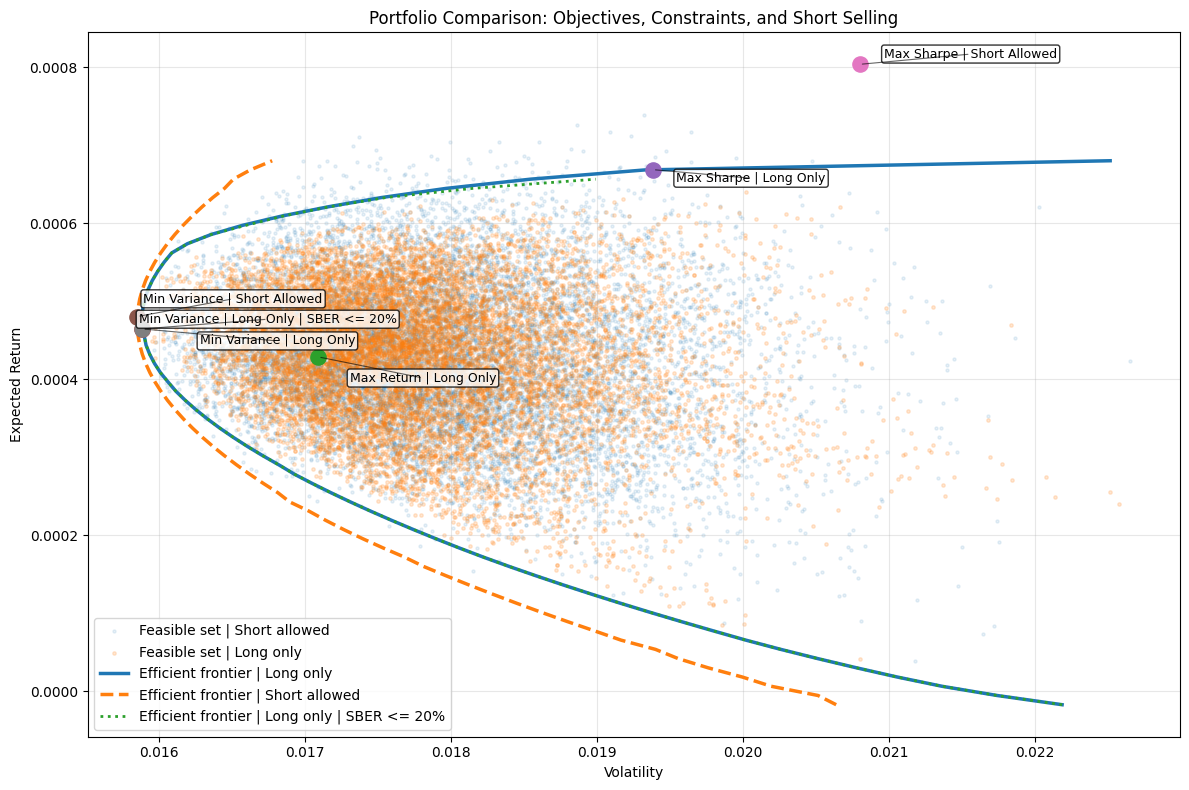

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    random_short["volatility"],
    random_short["return"],
    s=5,
    alpha=0.10,
    label="Feasible set | Short allowed"
)

plt.scatter(
    random_long["volatility"],
    random_long["return"],
    s=6,
    alpha=0.18,
    label="Feasible set | Long only"
)

plt.plot(
    frontier_long["volatility"],
    frontier_long["return"],
    linewidth=2.5,
    label="Efficient frontier | Long only"
)

plt.plot(
    frontier_short["volatility"],
    frontier_short["return"],
    linewidth=2.5,
    linestyle="--",
    label="Efficient frontier | Short allowed"
)

plt.plot(
    frontier_long_cap["volatility"],
    frontier_long_cap["return"],
    linewidth=2.0,
    linestyle=":",
    label="Efficient frontier | Long only | SBER <= 20%"
)

texts = []

for _, row in portfolios_df.iterrows():
    x = row["Volatility"]
    y = row["Expected Return"]

    plt.scatter(x, y, s=120, zorder=3)

    txt = plt.text(
        x,
        y,
        row["Portfolio"],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
    )
    texts.append(txt)

adjust_text(
    texts,
    x=portfolios_df["Volatility"].values,
    y=portfolios_df["Expected Return"].values,
    arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.6),
    force_text=(1.2, 1.2),
    force_static=(1.0, 1.0),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    ensure_inside_axes=True
)

plt.title("Portfolio Comparison: Objectives, Constraints, and Short Selling")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Re-run one portfolio using price returns only vs dividend-adjusted returns

This gives a direct side-by-side illustration of the role of dividends.

In [ ]:
mu_price = price_returns.mean().to_numpy(dtype=float)
cov_price = price_returns.cov().to_numpy(dtype=float)

mu_total = total_returns.mean().to_numpy(dtype=float)
cov_total = total_returns.cov().to_numpy(dtype=float)

w_price = optimize_portfolio(
    mu_vector=mu_price,
    cov_matrix=cov_price,
    objective="min_variance",
    rf=RISK_FREE_RATE,
    allow_short=False
)

w_total = optimize_portfolio(
    mu_vector=mu_total,
    cov_matrix=cov_total,
    objective="min_variance",
    rf=RISK_FREE_RATE,
    allow_short=False
)

comparison_rows = [
    evaluate_portfolio(
        "Min Variance | Long Only",
        w_price,
        TICKERS,
        mu_price,
        cov_price,
        RISK_FREE_RATE
    ),
    evaluate_portfolio(
        "Min Variance | Long Only",
        w_total,
        TICKERS,
        mu_total,
        cov_total,
        RISK_FREE_RATE
    )
]

comparison_portfolios = pd.DataFrame(comparison_rows)

display(
    comparison_portfolios[
        ["Portfolio", "Expected Return", "Volatility", "Sharpe"]
    ].style.format({
        "Expected Return": "{:.4%}",
        "Volatility": "{:.4%}",
        "Sharpe": "{:.3f}"
    })
)

weight_cols_cmp = [f"w_{t}" for t in TICKERS]

display(
    comparison_portfolios[["Portfolio"] + weight_cols_cmp].style.format("{:.2%}", subset=weight_cols_cmp)
)

,Portfolio,Expected Return,Volatility,Sharpe
0,Min Variance | Long Only,0.0117%,1.5870%,-0.030
1,Min Variance | Long Only,0.0464%,1.5888%,-0.008


,Portfolio,w_SBER,w_LKOH,w_MAGN,w_MTSS,w_AFLT,w_NVTK,w_MOEX
0,Min Variance | Long Only,0.00%,27.00%,11.61%,26.19%,0.00%,0.00%,35.21%
1,Min Variance | Long Only,0.00%,24.59%,14.75%,28.19%,0.00%,0.00%,32.47%


# Additional code

In [ ]:
TRADING_DAYS = 252

def equal_weight_portfolio(n_assets):
    return np.repeat(1 / n_assets, n_assets)


def annualize_return_from_series(return_series, periods_per_year=TRADING_DAYS):
    mean_ret = return_series.mean()
    return (1 + mean_ret) ** periods_per_year - 1


def annualize_vol_from_series(return_series, periods_per_year=TRADING_DAYS):
    return return_series.std() * np.sqrt(periods_per_year)


def max_drawdown(return_series):
    wealth = (1 + return_series).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min(), drawdown


def portfolio_series(returns_df, weights):
    weights = np.asarray(weights, dtype=float).reshape(-1)
    return returns_df @ weights


def risk_contributions(weights, cov_matrix):
    """
    Percentage contribution of each asset to portfolio variance.
    Contributions sum to 1.
    """
    weights = np.asarray(weights, dtype=float).reshape(-1)
    cov_matrix = np.asarray(cov_matrix, dtype=float)

    portfolio_var = weights @ cov_matrix @ weights
    marginal_contrib = cov_matrix @ weights
    contrib = weights * marginal_contrib

    if portfolio_var <= 1e-16:
        return np.repeat(np.nan, len(weights))

    return contrib / portfolio_var

## Build benchmark portfolios on daily data

We compare:

- Equal-weight portfolio
- Minimum-variance portfolio
- Maximum-Sharpe portfolio

In [ ]:
# Daily risk-free rate
RISK_FREE_RATE_DAILY = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS) - 1

# Daily inputs
mu_daily = returns.mean().to_numpy(dtype=float)
cov_daily = returns.cov().to_numpy(dtype=float)

# Portfolio weights
w_equal = equal_weight_portfolio(len(TICKERS))

w_min_var_daily = optimize_portfolio(
    mu_vector=mu_daily,
    cov_matrix=cov_daily,
    objective="min_variance",
    rf=RISK_FREE_RATE_DAILY,
    allow_short=False
)

w_max_sharpe_daily = optimize_portfolio(
    mu_vector=mu_daily,
    cov_matrix=cov_daily,
    objective="max_sharpe",
    rf=RISK_FREE_RATE_DAILY,
    allow_short=False
)

strategy_weights = pd.DataFrame({
    "Ticker": TICKERS,
    "Equal Weight": w_equal,
    "Min Variance": w_min_var_daily,
    "Max Sharpe": w_max_sharpe_daily
})

display(
    strategy_weights.style.format({
        "Equal Weight": "{:.2%}",
        "Min Variance": "{:.2%}",
        "Max Sharpe": "{:.2%}"
    })
)

,Ticker,Equal Weight,Min Variance,Max Sharpe
0,SBER,14.29%,0.00%,55.77%
1,LKOH,14.29%,24.59%,44.23%
2,MAGN,14.29%,14.75%,0.00%
3,MTSS,14.29%,28.19%,0.00%
4,AFLT,14.29%,0.00%,0.00%
5,NVTK,14.29%,0.00%,0.00%
6,MOEX,14.29%,32.47%,0.00%


## Cumulative performance of strategies

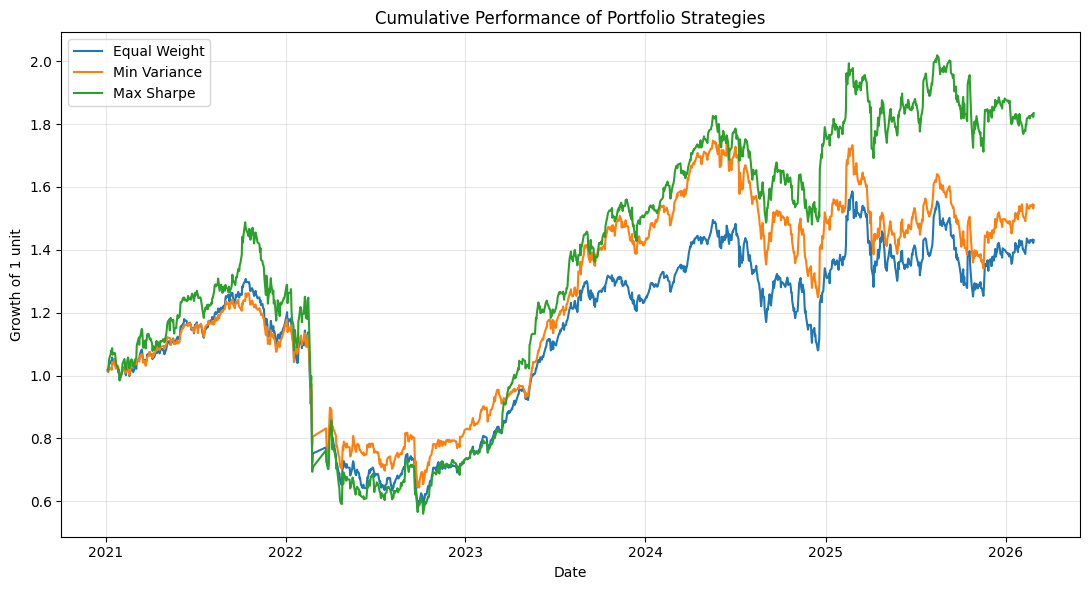

In [ ]:
strategy_returns = pd.DataFrame({
    "Equal Weight": portfolio_series(returns, w_equal),
    "Min Variance": portfolio_series(returns, w_min_var_daily),
    "Max Sharpe": portfolio_series(returns, w_max_sharpe_daily)
}, index=returns.index)

cumulative_index = (1 + strategy_returns).cumprod()

plt.figure(figsize=(11, 6))
for col in cumulative_index.columns:
    plt.plot(cumulative_index.index, cumulative_index[col], label=col)

plt.title("Cumulative Performance of Portfolio Strategies")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Rolling out-of-sample test

At each step:

- estimate the portfolio using a rolling training window,
- hold it for the next period,
- record realized out-of-sample return.

This is a simple way to compare in-sample optimization with out-of-sample performance.

In [ ]:
def rolling_backtest(
    returns_df,
    objective="max_sharpe",
    train_window=252,
    rebalance_step=21,
    rf_annual=0.16,
    allow_short=False
):
    rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1

    portfolio_returns = []
    portfolio_dates = []
    weights_history = []

    for start in range(0, len(returns_df) - train_window - rebalance_step + 1, rebalance_step):
        train = returns_df.iloc[start:start + train_window]
        test = returns_df.iloc[start + train_window:start + train_window + rebalance_step]

        mu_train = train.mean().to_numpy(dtype=float)
        cov_train = train.cov().to_numpy(dtype=float)

        weights = optimize_portfolio(
            mu_vector=mu_train,
            cov_matrix=cov_train,
            objective=objective,
            rf=rf_daily,
            allow_short=allow_short
        )

        realized = test @ weights

        portfolio_returns.append(realized)
        portfolio_dates.append(realized.index)
        weights_history.append(pd.Series(weights, index=returns_df.columns, name=test.index[0]))

    portfolio_returns = pd.concat(portfolio_returns)
    weights_history = pd.DataFrame(weights_history)

    return portfolio_returns, weights_history

In [ ]:
rolling_max_sharpe, rolling_weights_max_sharpe = rolling_backtest(
    returns_df=returns,
    objective="max_sharpe",
    train_window=252,
    rebalance_step=21,
    rf_annual=RISK_FREE_RATE_ANNUAL,
    allow_short=False
)

rolling_min_var, rolling_weights_min_var = rolling_backtest(
    returns_df=returns,
    objective="min_variance",
    train_window=252,
    rebalance_step=21,
    rf_annual=RISK_FREE_RATE_ANNUAL,
    allow_short=False
)

rolling_equal = returns.loc[rolling_max_sharpe.index] @ w_equal

rolling_strategies = pd.DataFrame({
    "Equal Weight (Rolling Period)": rolling_equal,
    "Rolling Min Variance": rolling_min_var,
    "Rolling Max Sharpe": rolling_max_sharpe
}).dropna()

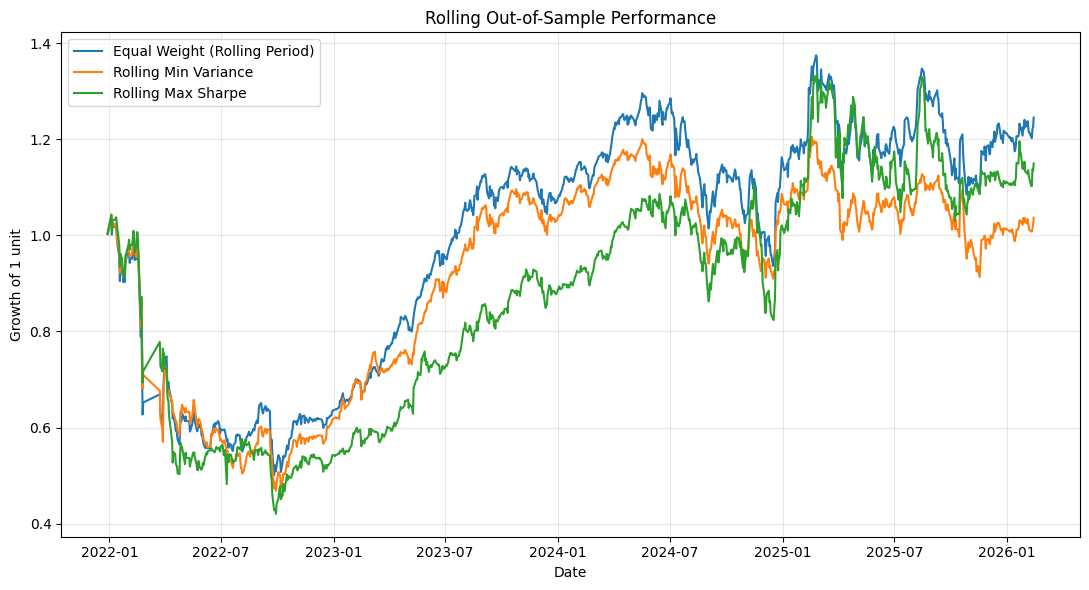

In [ ]:
rolling_cum = (1 + rolling_strategies).cumprod()

plt.figure(figsize=(11, 6))
for col in rolling_cum.columns:
    plt.plot(rolling_cum.index, rolling_cum[col], label=col)

plt.title("Rolling Out-of-Sample Performance")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
rolling_rows = []

for col in rolling_strategies.columns:
    series = rolling_strategies[col]
    mdd, _ = max_drawdown(series)

    rolling_rows.append({
        "Strategy": col,
        "Annualized Return": annualize_return_from_series(series),
        "Annualized Volatility": annualize_vol_from_series(series),
        "Sharpe": (series.mean() - RISK_FREE_RATE_DAILY) / series.std(),
        "Max Drawdown": mdd
    })

rolling_df = pd.DataFrame(rolling_rows)

display(
    rolling_df.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe": "{:.3f}",
        "Max Drawdown": "{:.2%}"
    })
)

,Strategy,Annualized Return,Annualized Volatility,Sharpe,Max Drawdown
0,Equal Weight (Rolling Period),10.34%,29.38%,-0.011,-51.90%
1,Rolling Min Variance,5.23%,28.78%,-0.021,-55.16%
2,Rolling Max Sharpe,9.70%,33.95%,-0.010,-59.65%


## Compare daily vs monthly optimization

In [ ]:
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

RISK_FREE_RATE_MONTHLY = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / 12) - 1

mu_monthly = monthly_returns.mean().to_numpy(dtype=float)
cov_monthly = monthly_returns.cov().to_numpy(dtype=float)

w_min_var_monthly = optimize_portfolio(
    mu_vector=mu_monthly,
    cov_matrix=cov_monthly,
    objective="min_variance",
    rf=RISK_FREE_RATE_MONTHLY,
    allow_short=False
)

w_max_sharpe_monthly = optimize_portfolio(
    mu_vector=mu_monthly,
    cov_matrix=cov_monthly,
    objective="max_sharpe",
    rf=RISK_FREE_RATE_MONTHLY,
    allow_short=False
)

daily_monthly_compare = pd.DataFrame({
    "Ticker": TICKERS,
    "Min Variance | Daily": w_min_var_daily,
    "Min Variance | Monthly": w_min_var_monthly,
    "Max Sharpe | Daily": w_max_sharpe_daily,
    "Max Sharpe | Monthly": w_max_sharpe_monthly
})

display(
    daily_monthly_compare.style.format({
        "Min Variance | Daily": "{:.2%}",
        "Min Variance | Monthly": "{:.2%}",
        "Max Sharpe | Daily": "{:.2%}",
        "Max Sharpe | Monthly": "{:.2%}"
    })
)

,Ticker,Min Variance | Daily,Min Variance | Monthly,Max Sharpe | Daily,Max Sharpe | Monthly
0,SBER,0.00%,0.00%,55.77%,100.00%
1,LKOH,24.59%,29.63%,44.23%,0.00%
2,MAGN,14.75%,9.82%,0.00%,0.00%
3,MTSS,28.19%,33.57%,0.00%,0.00%
4,AFLT,0.00%,0.00%,0.00%,0.00%
5,NVTK,0.00%,0.00%,0.00%,0.00%
6,MOEX,32.47%,26.98%,0.00%,0.00%


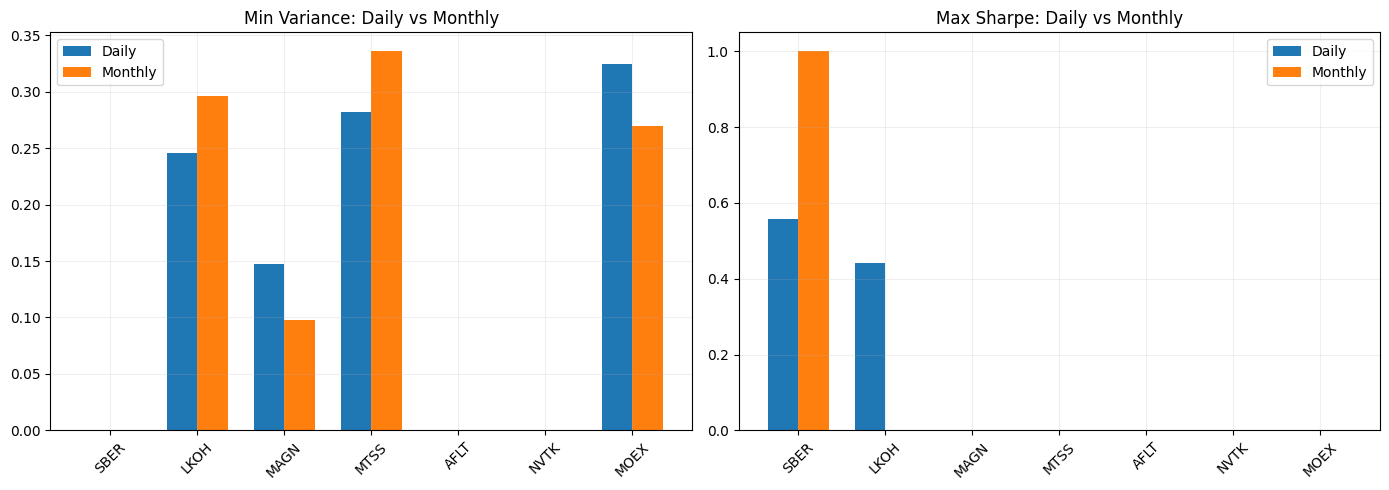

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(TICKERS))
width = 0.35

# Min variance comparison
axes[0].bar(x - width/2, w_min_var_daily, width, label="Daily")
axes[0].bar(x + width/2, w_min_var_monthly, width, label="Monthly")
axes[0].set_title("Min Variance: Daily vs Monthly")
axes[0].set_xticks(x)
axes[0].set_xticklabels(TICKERS, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Max Sharpe comparison
axes[1].bar(x - width/2, w_max_sharpe_daily, width, label="Daily")
axes[1].bar(x + width/2, w_max_sharpe_monthly, width, label="Monthly")
axes[1].set_title("Max Sharpe: Daily vs Monthly")
axes[1].set_xticks(x)
axes[1].set_xticklabels(TICKERS, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Contribution to risk by asset

In [ ]:
rc_min_var = risk_contributions(w_min_var_daily, cov_daily)
rc_max_sharpe = risk_contributions(w_max_sharpe_daily, cov_daily)

risk_contrib_df = pd.DataFrame({
    "Ticker": TICKERS,
    "Weight | Min Variance": w_min_var_daily,
    "Risk Contribution | Min Variance": rc_min_var,
    "Weight | Max Sharpe": w_max_sharpe_daily,
    "Risk Contribution | Max Sharpe": rc_max_sharpe
})

display(
    risk_contrib_df.style.format({
        "Weight | Min Variance": "{:.2%}",
        "Risk Contribution | Min Variance": "{:.2%}",
        "Weight | Max Sharpe": "{:.2%}",
        "Risk Contribution | Max Sharpe": "{:.2%}"
    })
)

,Ticker,Weight | Min Variance,Risk Contribution | Min Variance,Weight | Max Sharpe,Risk Contribution | Max Sharpe
0,SBER,0.00%,0.00%,55.77%,60.40%
1,LKOH,24.59%,24.57%,44.23%,39.60%
2,MAGN,14.75%,15.03%,0.00%,0.00%
3,MTSS,28.19%,28.55%,0.00%,0.00%
4,AFLT,0.00%,0.00%,0.00%,0.00%
5,NVTK,0.00%,0.00%,0.00%,0.00%
6,MOEX,32.47%,31.86%,0.00%,0.00%


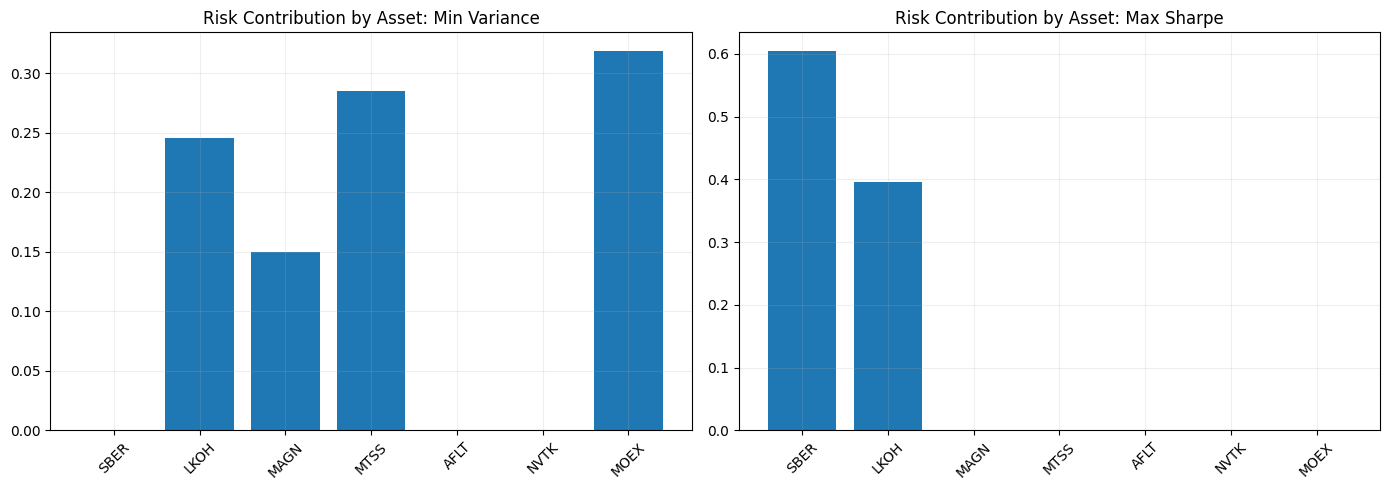

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(TICKERS, rc_min_var)
axes[0].set_title("Risk Contribution by Asset: Min Variance")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.2)

axes[1].bar(TICKERS, rc_max_sharpe)
axes[1].set_title("Risk Contribution by Asset: Max Sharpe")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Limits of Diversification

We now move from portfolio optimization to a different question:

**Does diversification reduce risk indefinitely?**

To answer this, we expand the number of stocks and examine how average portfolio volatility changes as the number of assets increases.

The expected result is:

- a sharp decline in risk at first,
- then a gradual flattening,
- and finally a plateau.

This is the empirical illustration of the theoretical limit of diversification.

## Define the diversification experiment

For each portfolio size:

- randomly choose `k` assets,
- randomly assign weights,
- compute portfolio volatility,
- repeat many times,
- and summarize the average, minimum, and maximum volatility.

This allows us to see how portfolio risk behaves as the number of assets increases.

In [ ]:
# SETTINGS FOR DIVERSIFICATION DEMO
TICKERS_LARGE = [
    "SBER", "GAZP", "LKOH", "GMKN", "NVTK",
    "ROSN", "TATN", "PLZL", "MGNT", "CHMF",
    "ALRS", "MOEX", "MTSS", "SNGS", "IRAO"
]

In [ ]:
prices_large = load_prices(TICKERS_LARGE, START_DATE, END_DATE)
returns_large = prices_large.pct_change().dropna()

print("Number of assets loaded:", len(prices_large.columns))
print(prices_large.columns.tolist())

Loading SBER...
Loading GAZP...
Loading LKOH...
Loading GMKN...
Loading NVTK...
Loading ROSN...
Loading TATN...
Loading PLZL...
Loading MGNT...
Loading CHMF...
Loading ALRS...
Loading MOEX...
Loading MTSS...
Loading SNGS...
Loading IRAO...
Number of assets loaded: 15
['SBER', 'GAZP', 'LKOH', 'GMKN', 'NVTK', 'ROSN', 'TATN', 'PLZL', 'MGNT', 'CHMF', 'ALRS', 'MOEX', 'MTSS', 'SNGS', 'IRAO']


In [ ]:
def diversification_plateau_demo(returns, n_trials=1000, seed=42):
    rng = np.random.default_rng(seed)
    annual_cov = returns.cov() * 252
    asset_names = list(returns.columns)

    results = []

    for k in range(1, len(asset_names) + 1):
        vols = []

        for _ in range(n_trials):
            chosen_assets = rng.choice(asset_names, size=k, replace=False)
            sub_cov = annual_cov.loc[chosen_assets, chosen_assets].values

            weights = rng.random(k)
            weights = weights / weights.sum()

            vol = np.sqrt(weights.T @ sub_cov @ weights)
            vols.append(vol)

        results.append({
            "n_assets": k,
            "avg_vol": np.mean(vols),
            "min_vol": np.min(vols),
            "max_vol": np.max(vols)
        })

    return pd.DataFrame(results)

In [ ]:
div_df = diversification_plateau_demo(returns_large, n_trials=1500)
display(div_df.round(4))

,n_assets,avg_vol,min_vol,max_vol
0,1,0.3777,0.2994,0.5434
1,2,0.3403,0.2680,0.5418
2,3,0.3177,0.2619,0.5002
3,4,0.3059,0.2567,0.4422
4,5,0.2977,0.2540,0.4376
5,6,0.2915,0.2497,0.3513
6,7,0.2871,0.2585,0.3356
7,8,0.2835,0.2584,0.3509
8,9,0.2815,0.2586,0.3089
9,10,0.2796,0.2568,0.3135


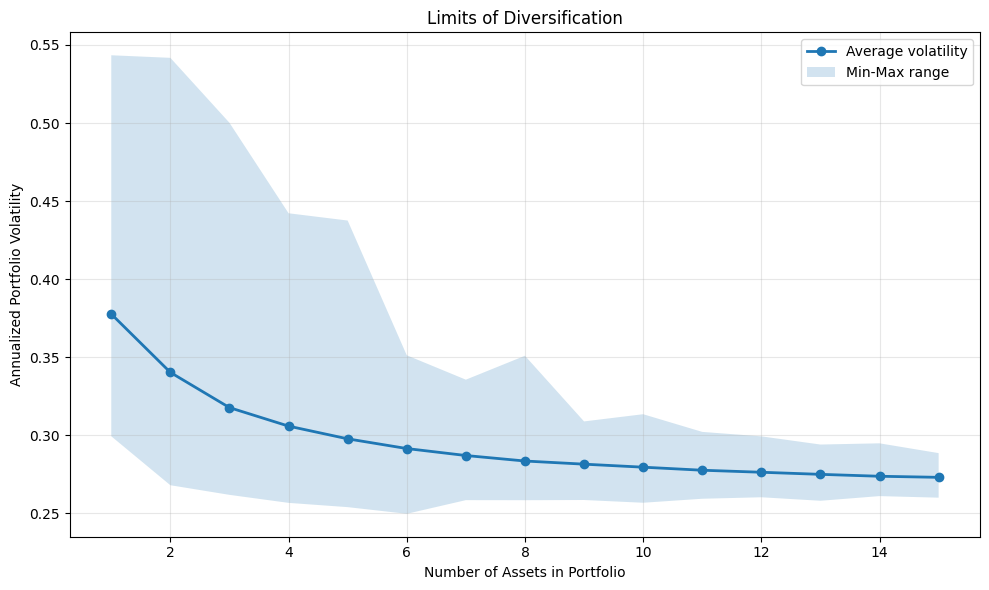

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    div_df["n_assets"],
    div_df["avg_vol"],
    marker="o",
    linewidth=2,
    label="Average volatility"
)

plt.fill_between(
    div_df["n_assets"],
    div_df["min_vol"],
    div_df["max_vol"],
    alpha=0.2,
    label="Min-Max range"
)

plt.title("Limits of Diversification")
plt.xlabel("Number of Assets in Portfolio")
plt.ylabel("Annualized Portfolio Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()